In [ ]:
#KAVIBHARATHI K
#212224220045

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Model(nn.Module):
    
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        # Input Layers (4 features) ---> h1 --> h2 ---> output (3 classes)
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)   # input layer
        self.fc2 = nn.Linear(h1, h2)            # hidden layer
        self.out = nn.Linear(h2, out_features)  # output layer
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [3]:
# Instantiate the Model class using parameter defaults:
torch.manual_seed(32)
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# FIX: Load iris dataset directly from sklearn (no CSV file needed)
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [7]:
# Features and labels
X = df.drop('target', axis=1).values
y = df['target'].values

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test  = torch.LongTensor(y_test)

In [9]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [10]:
# Train the model
epochs = 100
losses = []

for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())

    if i % 10 == 0:
        print(f'Epoch {i} Loss: {loss.item():.4f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0 Loss: 1.1507
Epoch 10 Loss: 0.9371
Epoch 20 Loss: 0.7796
Epoch 30 Loss: 0.6079
Epoch 40 Loss: 0.3989
Epoch 50 Loss: 0.2525
Epoch 60 Loss: 0.1493
Epoch 70 Loss: 0.1003
Epoch 80 Loss: 0.0810
Epoch 90 Loss: 0.0722


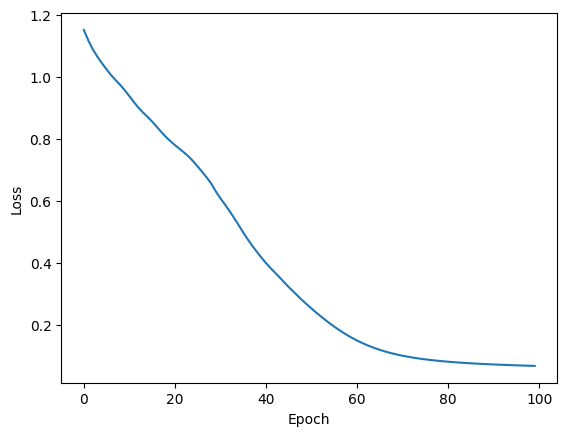

In [11]:
plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('Epoch');

In [12]:
correct = 0

with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)
        print(f'{i+1}.) {str(y_val)} {y_test[i]}')
        if y_val.argmax().item() == y_test[i]:
            correct += 1

print(f'We got {correct} correct!')

1.) tensor([-2.1234,  4.8067, -0.8803]) 1
2.) tensor([-1.7920,  5.3100, -1.5693]) 1
3.) tensor([  6.3723,   0.8741, -10.0971]) 0
4.) tensor([-3.9129,  4.5951,  1.1509]) 1
5.) tensor([-7.4882,  3.1953,  5.7839]) 2
6.) tensor([-10.5202,   1.6381,   9.6291]) 2
7.) tensor([  6.3364,   1.0237, -10.1951]) 0
8.) tensor([  7.0690,   0.7370, -10.9620]) 0
9.) tensor([-7.2218,  3.3422,  5.3528]) 2
10.) tensor([-9.4170,  2.5675,  8.1028]) 2
11.) tensor([-9.9029,  2.3388,  8.7141]) 2
12.) tensor([ 6.2942,  0.6938, -9.8046]) 0
13.) tensor([-9.3335,  2.1817,  8.1917]) 2
14.) tensor([-3.7832,  4.5046,  1.0603]) 1
15.) tensor([-7.8793,  3.0060,  6.2225]) 2
16.) tensor([-1.8810,  5.1571, -1.3572]) 1
17.) tensor([-5.7107,  3.5003,  3.6612]) 2
18.) tensor([  7.2014,   0.7687, -11.1842]) 0
19.) tensor([-3.2961,  4.7939,  0.3307]) 1
20.) tensor([-7.7822,  3.7560,  5.7040]) 2
21.) tensor([  6.6703,   0.8191, -10.4707]) 0
22.) tensor([  7.4580,   0.9259, -11.7103]) 0
23.) tensor([-9.7801,  2.1658,  8.6656]) 2

In [13]:
print(f'{i+1}.) {str(y_val.argmax().item())} {y_test[i]}')

30.) 2 2


In [14]:
# Save the trained model
torch.save(model.state_dict(), 'my_iris_model.pt')
print('Model saved as my_iris_model.pt')

Model saved as my_iris_model.pt


In [15]:
# Reload and evaluate the saved model
# FIX: Use the correct architecture (matching the saved model: h1=8, h2=9)
# FIX: Load from correct filename 'my_iris_model.pt'

new_model = Model()  # same architecture as original
new_model.load_state_dict(torch.load('my_iris_model.pt'))
new_model.eval()
print('Model loaded successfully!')

Model loaded successfully!


In [16]:
# Test new_model on a sample
sample = X_test[0].unsqueeze(0)
with torch.no_grad():
    out = new_model(sample)
    pred = out.argmax().item()
print(f'Predicted class: {pred}, Actual class: {y_test[0].item()}')

Predicted class: 1, Actual class: 1
